# N2 · Prior ensemble conditions

**This notebook reads only `data/3D_subsets_*`. It touches no assimilation output
of any kind.** Everything here describes the forecast ensemble *before* any
observation is used, which is what makes it a fair place to choose the hour and
the sub-box that the assimilation experiments will target.

### The two dataset families

| label | directory | upstream WRF experiment |
|---|---|---|
| **A** | `3D_subsets_20240319_GUES_SINGLECONF_<HH>` | `PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF` |
| **B** | `3D_subsets_20240319_GUES_SINGLECONF_<HH>_1HR` | `PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900` |

They come from **different upstream experiments** and share a grid. This notebook
labels them A and B and compares them descriptively; it deliberately asserts
nothing about *why* they differ, because that difference is a property of the
upstream DA configuration and is not recoverable from these files.

Reflectivity is not stored in the subsets — it is computed here from
`qr/qs/qg/T/P` with the same operator the assimilation uses
(`nbcommon.hx`, pinned to the Fortran `calc_ref` at import).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import nbcommon as nb
nb.banner()

# ── configuration ──────────────────────────────────────────────────────────
HOURS    = ["18", "19", "20", "21"]
FAMILIES = {"A": "", "B": "_1HR"}
MIN_DBZ  = 0.0            # matches qc.dbz_min + clamp_obs in the run configs
BBOX     = None           # set in section 6

PATHS = {(fam, h): nb.subset_path(h, family=suf)
         for fam, suf in FAMILIES.items() for h in HOURS}

SIGN CONVENTION -- one rule, enforced by this module.

  Every quantity named `skill` is  prior - analysis.
  POSITIVE MEANS THE ANALYSIS IS BETTER THAN THE PRIOR.

  There is no other difference in this module. nbcommon exports no `drmse`, no
  `delta`, no `d_*`. skill() is the only function that subtracts a prior from an
  analysis, and it always subtracts in that order.

  `spread` is NOT a skill metric -- lower spread is not better -- and
  skill(metric='spread') raises.

  `bias`, `skew` and `kurt` are compared as magnitudes: skill = |prior| - |analysis|.
  (skew/kurt at the _w_/_u_ reductions are already stored as means of |.|, so the
  magnitude is not taken twice; see da/metrics.py.)

  Colour: CMAP_SKILL is blue at positive (better), red at negative (worse), always
  centred on 0. It is used with skill() output and nothing else.

  Column names are NATIVE and the variable suffix is LAST:
      crps_f_w_w   = loc-weighted CRPS of vertical wind
      rmse_f_u_u   = unweighted   

In [2]:
# Every file must be readable AND the grids must match, or no comparison is valid.
rows = []
for (fam, h), p in sorted(PATHS.items()):
    status, detail = nb.check_subset(p)
    k = nb.peek_npz(p) if status == "PASS" else {}
    se = k.get("state_ensemble", ((None,) * 5,))[0]
    rows.append(dict(family=fam, hour=h, status=status,
                     nx=se[0], ny=se[1], nz=se[2], Ne=se[3], detail=detail))
inv = pd.DataFrame(rows)
print(inv.to_string(index=False))

assert (inv.status == "PASS").all(), "some inputs failed N1's health sweep"
for c in ("nx", "ny", "nz", "Ne"):
    assert inv[c].nunique() == 1, f"{c} differs across files -- grids are not comparable"
NE = int(inv["Ne"].iloc[0])
print(f"\ngrids match: {inv.nx[0]} x {inv.ny[0]} x {inv.nz[0]}, Ne = {NE}")

family hour status  nx  ny  nz  Ne          detail
     A   18   PASS 307 451  11  60 307x451x11x60x8
     A   19   PASS 307 451  11  60 307x451x11x60x8
     A   20   PASS 307 451  11  60 307x451x11x60x8
     A   21   PASS 307 451  11  60 307x451x11x60x8
     B   18   PASS 307 451  11  60 307x451x11x60x8
     B   19   PASS 307 451  11  60 307x451x11x60x8
     B   20   PASS 307 451  11  60 307x451x11x60x8
     B   21   PASS 307 451  11  60 307x451x11x60x8

grids match: 307 x 451 x 11, Ne = 60


## 1 · The event

Column-maximum of the **ensemble-mean** reflectivity. Rows are the two dataset
families, columns the four valid times. Same colour scale everywhere, so the
panels are directly comparable.

The first call per file decompresses several GB and caches the result to
`data/derived/`; later calls are effectively instant.

In [3]:
STATS = {key: nb.prior_stats(p, bbox=BBOX, min_dbz=MIN_DBZ) for key, p in PATHS.items()}
GEO   = nb.load_subset(PATHS[("A", HOURS[0])], keys=("lats", "lons", "pos_km", "z_heights"))
Z_KM  = GEO["pos_km"][0, 0, :, 2]
print("cached. z levels [km]:", np.round(Z_KM, 2))

cached. z levels [km]: [ 0.25  0.5   1.    2.    3.    4.    5.    6.    8.   10.   12.  ]


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


saved N2_fig1_mean_reflectivity.pdf / N2_fig1_mean_reflectivity.png


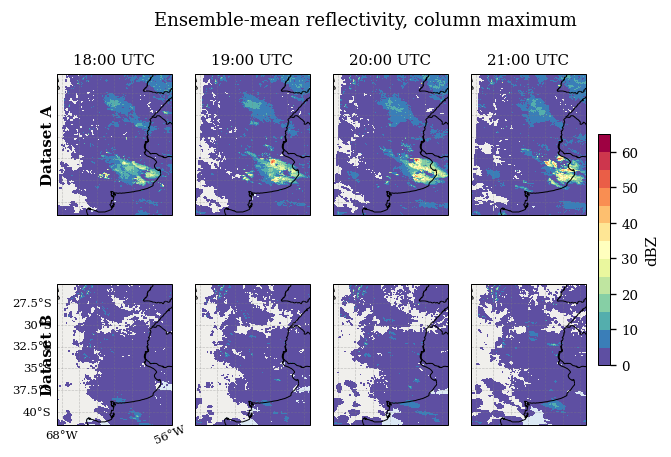

In [4]:
def grid_of_maps(field_fn, title, cbar_label, **kw):
    fig, axes = plt.subplots(len(FAMILIES), len(HOURS),
                             figsize=(nb.PAGE_W, nb.PAGE_W * 0.62),
                             subplot_kw=dict(projection=ccrs.PlateCarree()))
    axes = np.atleast_2d(axes)
    for r, fam in enumerate(FAMILIES):
        for c, h in enumerate(HOURS):
            ax = axes[r, c]
            nb.setup_map(ax, labels=(r == len(FAMILIES) - 1 and c == 0))
            f = field_fn(STATS[(fam, h)])
            pm = nb.map_field(ax, GEO["lats"], GEO["lons"],
                              np.where(np.isfinite(f) & (f > 0), f, np.nan),
                              transform=ccrs.PlateCarree(), **kw)
            if r == 0:
                ax.set_title(f"{h}:00 UTC")
            if c == 0:
                ax.text(-0.08, 0.5, f"Dataset {fam}", transform=ax.transAxes,
                        rotation=90, va="center", ha="center", fontweight="bold")
    fig.colorbar(pm, ax=axes, shrink=0.6, pad=0.02, label=cbar_label)
    fig.suptitle(title, y=0.97)
    return fig

fig = grid_of_maps(lambda s: np.nanmax(s["dbz_mean"], axis=2),
                   "Ensemble-mean reflectivity, column maximum",
                   "dBZ", cmap=nb.DBZ_CMAP, norm=nb.DBZ_NORM)
nb.save_fig(fig, "N2_fig1_mean_reflectivity")
plt.show()

The ensemble mean smooths across members, so it understates peak intensity — a
cell that only a few members produce shows up weak here. That is precisely what
the next two figures separate out.

saved N2_fig2_spread.pdf / N2_fig2_spread.png


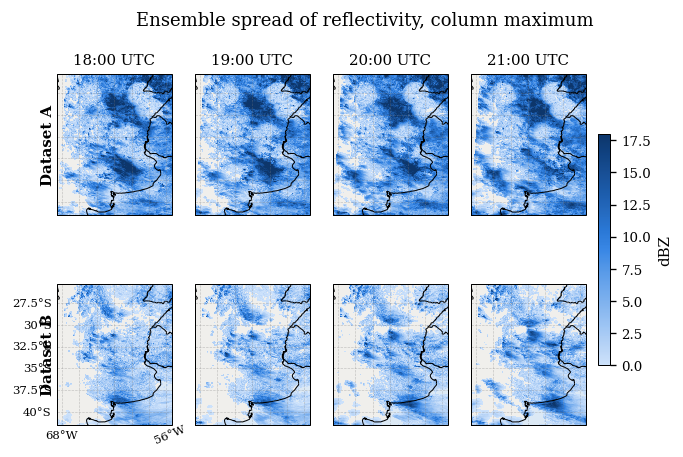

In [5]:
fig = grid_of_maps(lambda s: np.nanmax(s["dbz_spread"], axis=2),
                   "Ensemble spread of reflectivity, column maximum",
                   "dBZ", cmap=nb.CMAP_SEQ, vmin=0, vmax=18)
nb.save_fig(fig, "N2_fig2_spread")
plt.show()

## 2 · How many members carry signal

`n_active` counts members with `H(x) > dbz_min` at each grid point. It is the
prior field that matters most downstream: where only a handful of members produce
an echo, the ensemble covariance in observation space is estimated from those few
members, and the analysis increment inherits their sampling noise. N3 uses it as
the primary predictor of degradation.

saved N2_fig3a_n_active_maps.pdf / N2_fig3a_n_active_maps.png


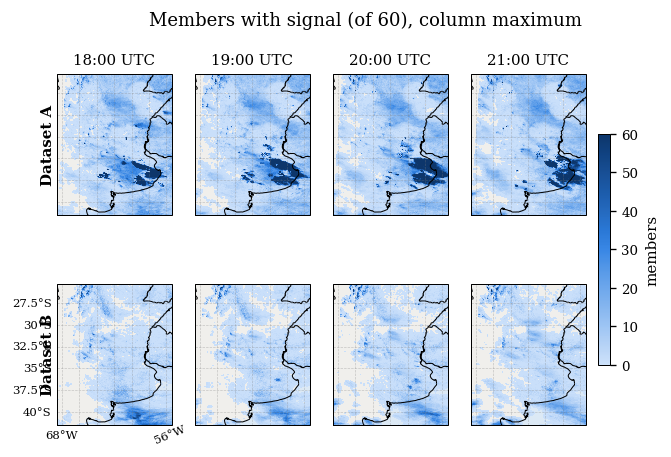

saved N2_fig3b_n_active_hist.pdf / N2_fig3b_n_active_hist.png


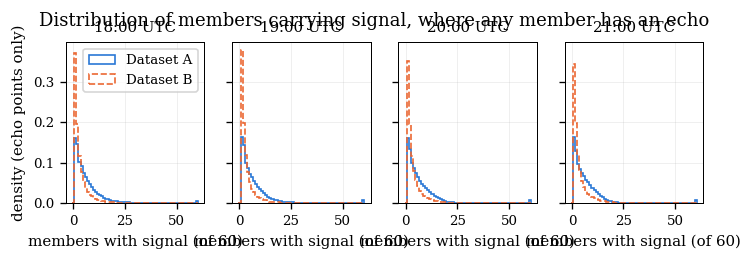

In [6]:
fig = grid_of_maps(lambda s: np.nanmax(s["n_active"].astype(float), axis=2),
                   f"Members with signal (of {NE}), column maximum",
                   "members", cmap=nb.CMAP_SEQ, vmin=0, vmax=NE)
nb.save_fig(fig, "N2_fig3a_n_active_maps")
plt.show()

fig, axes = plt.subplots(1, len(HOURS), figsize=(nb.PAGE_W, nb.PAGE_W * 0.26),
                         sharey=True)
for ax, h in zip(np.atleast_1d(axes), HOURS):
    for fam, ls in zip(FAMILIES, ["-", "--"]):
        na = STATS[(fam, h)]["n_active"].ravel()
        na = na[na > 0]                      # drop wholly clear-air points
        ax.hist(na, bins=np.arange(0, NE + 2) - 0.5, histtype="step", ls=ls,
                density=True, label=f"Dataset {fam}",
                color=nb.C_NT2 if fam == "A" else nb.C_NT1)
    ax.set_title(f"{h}:00 UTC"); ax.set_xlabel(f"members with signal (of {NE})")
np.atleast_1d(axes)[0].set_ylabel("density (echo points only)")
np.atleast_1d(axes)[0].legend()
fig.suptitle("Distribution of members carrying signal, where any member has an echo", y=1.02)
nb.save_fig(fig, "N2_fig3b_n_active_hist")
plt.show()

## 3 · Member-to-member disagreement

Each thin line is the 30-dBZ column-max contour of one member; the black line is
the same contour of the ensemble mean. Where the thin lines scatter widely the
members disagree about *where* convection is, which is a harder problem for the
filter than disagreeing about how intense it is.

/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1478: UserWarning: No contour levels were found within the data range.
  result = matplotlib.axes.Axes.contour(self, *args, **kwargs)


saved N2_fig4_spaghetti.pdf / N2_fig4_spaghetti.png


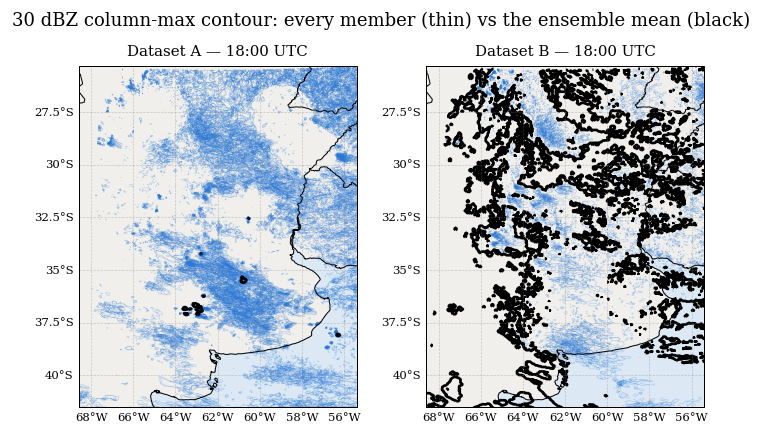

In [7]:
H_SHOW = HOURS[0]
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(nb.PAGE_W, nb.PAGE_W * 0.55),
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
for ax, fam in zip(np.atleast_1d(axes), FAMILIES):
    nb.setup_map(ax)
    s = STATS[(fam, H_SHOW)]
    cm = s["dbz_colmax_members"]                      # (nx, ny, Ne)
    for m in range(cm.shape[2]):
        ax.contour(GEO["lons"], GEO["lats"], cm[:, :, m].T, levels=[30.0],
                   colors=[nb.C_NT2], linewidths=0.35, alpha=0.30,
                   transform=ccrs.PlateCarree())
    ax.contour(GEO["lons"], GEO["lats"], np.nanmax(s["dbz_mean"], axis=2).T,
               levels=[30.0], colors="black", linewidths=1.6,
               transform=ccrs.PlateCarree())
    ax.set_title(f"Dataset {fam} — {H_SHOW}:00 UTC")
fig.suptitle("30 dBZ column-max contour: every member (thin) vs the ensemble mean (black)",
             y=1.0)
nb.save_fig(fig, "N2_fig4_spaghetti")
plt.show()

## 4 · Vertical structure

Domain medians over echo points only (`n_active > 0`); including clear air would
just measure how much clear air each level has. Skewness and excess kurtosis come
from `da.metrics`, the same functions the assimilation diagnostics use — a
Gaussian ensemble would sit at 0 on both.

saved N2_fig5_profiles.pdf / N2_fig5_profiles.png


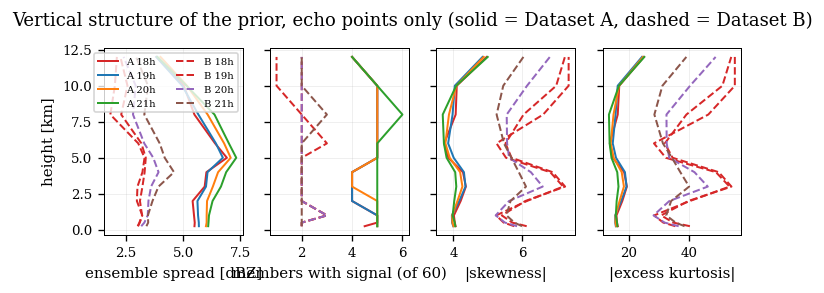

In [8]:
QTY = [("dbz_spread", "ensemble spread [dBZ]", np.nanmedian),
       ("n_active",   f"members with signal (of {NE})", np.nanmedian),
       ("dbz_skew",   "|skewness|", lambda a, axis: np.nanmedian(np.abs(a), axis=axis)),
       ("dbz_kurt",   "|excess kurtosis|", lambda a, axis: np.nanmedian(np.abs(a), axis=axis))]

fig, axes = plt.subplots(1, len(QTY), figsize=(nb.PAGE_W, nb.PAGE_W * 0.30), sharey=True)
for ax, (key, lab, red) in zip(axes, QTY):
    for fam, ls in zip(FAMILIES, ["-", "--"]):
        for h in HOURS:
            s = STATS[(fam, h)]
            echo = s["n_active"] > 0
            prof = np.array([red(np.where(echo[:, :, kk], s[key][:, :, kk].astype(float),
                                          np.nan), axis=None) for kk in range(len(Z_KM))])
            ax.plot(prof, Z_KM, ls=ls, lw=1.2, color=nb.loc_color(0.1) if h == "18" else None,
                    label=f"{fam} {h}h" if key == "dbz_spread" else None)
    ax.set_xlabel(lab)
axes[0].set_ylabel("height [km]")
axes[0].legend(fontsize=6, ncol=2)
fig.suptitle("Vertical structure of the prior, echo points only "
             "(solid = Dataset A, dashed = Dataset B)", y=1.03)
nb.save_fig(fig, "N2_fig5_profiles")
plt.show()

saved N2_fig6_cross_section.pdf / N2_fig6_cross_section.png


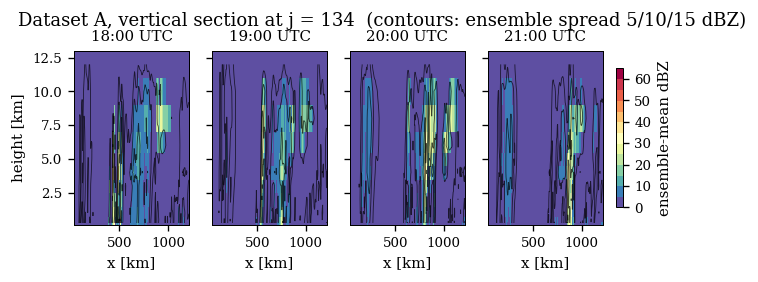

In [9]:
# Vertical cross-section through the most active row of the domain.
fam, h = "A", HOURS[0]
s = STATS[(fam, h)]
J0 = int(np.nanargmax(np.nanmax(s["dbz_mean"], axis=2).sum(axis=0)))
x_km = GEO["pos_km"][:, J0, 0, 0]

fig, axes = plt.subplots(1, len(HOURS), figsize=(nb.PAGE_W, nb.PAGE_W * 0.28),
                         sharey=True, sharex=True)
for ax, hh in zip(np.atleast_1d(axes), HOURS):
    ss = STATS[(fam, hh)]
    im = nb._panel(ax, ss["dbz_mean"][:, J0, :].T, x_km, Z_KM,
                   xlabel="x [km]", ylabel="height [km]" if hh == HOURS[0] else "",
                   title=f"{hh}:00 UTC", cmap=nb.DBZ_CMAP, norm=nb.DBZ_NORM)
    ax.contour(x_km, Z_KM, ss["dbz_spread"][:, J0, :].T, levels=[5, 10, 15],
               colors="k", linewidths=0.5, alpha=0.7)
fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, label="ensemble-mean dBZ")
fig.suptitle(f"Dataset {fam}, vertical section at j = {J0}  "
             f"(contours: ensemble spread 5/10/15 dBZ)", y=1.05)
nb.save_fig(fig, "N2_fig6_cross_section")
plt.show()

## 5 · State variables, not only reflectivity

Only reflectivity is observed, but the filter updates all eight state variables
through their cross-covariance with it. Where the prior spread of an *unobserved*
variable is large, the analysis increment there is large too — and nothing in
observation space constrains whether it went the right way. `u`, `v` and `w` are
the ones to watch.

/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


saved N2_fig7_state_spread.pdf / N2_fig7_state_spread.png


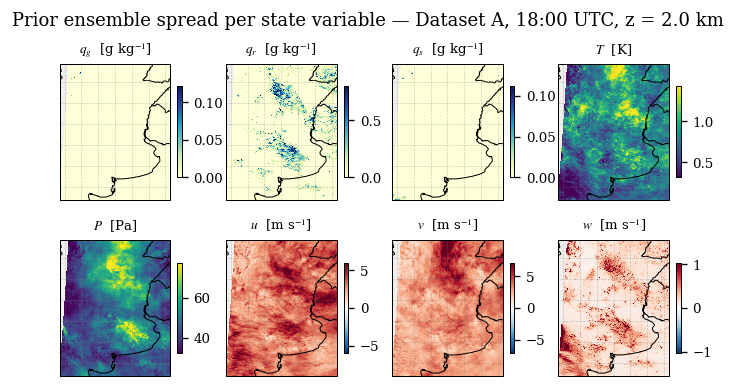

In [10]:
K_SHOW = 3
fam, h  = "A", HOURS[0]
s = STATS[(fam, h)]

fig, axes = plt.subplots(2, 4, figsize=(nb.PAGE_W, nb.PAGE_W * 0.52),
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
for ax, v in zip(axes.ravel(), nb.VARS):
    nb.setup_map(ax, labels=False)
    f = nb.disp(s[f"spread_{v}"][:, :, K_SHOW], v)
    pm = nb.map_field(ax, GEO["lats"], GEO["lons"], f,
                      transform=ccrs.PlateCarree(),
                      **{k: val for k, val in nb.scales([f], v).items()})
    ax.set_title(f"{nb.VAR_LABELS[v]}  [{nb.disp_unit(v)}]", fontsize=8)
    plt.colorbar(pm, ax=ax, shrink=0.62)
fig.suptitle(f"Prior ensemble spread per state variable — Dataset {fam}, "
             f"{h}:00 UTC, z = {Z_KM[K_SHOW]:.1f} km", y=0.99)
nb.save_fig(fig, "N2_fig7_state_spread")
plt.show()

## 6 · Zoom: redo the analysis inside a sub-box

This is how the assimilation target region gets chosen. Set `BBOX` below, and the
same statistics are recomputed on the sub-box only. Compare the `n_active`
distribution inside the box against the full domain: a box dominated by clear air
gives the filter very little to work with.

In [11]:
BBOX_LL = dict(lat=(-38.0, -31.0), lon=(-64.0, -56.0))
si, sj  = nb.bbox_to_slices(GEO["lats"], GEO["lons"], BBOX_LL["lat"], BBOX_LL["lon"])
print(f"box slices: i {si.start}:{si.stop}  j {sj.start}:{sj.stop}  "
      f"({(si.stop-si.start) * (sj.stop-sj.start):,} of "
      f"{GEO['lats'].size:,} columns = "
      f"{100*(si.stop-si.start)*(sj.stop-sj.start)/GEO['lats'].size:.1f} %)")

BOX = {key: nb.prior_stats(p, bbox=(si, sj), min_dbz=MIN_DBZ)
       for key, p in PATHS.items()}
GEO_BOX = dict(lats=GEO["lats"][sj, si], lons=GEO["lons"][sj, si])

box slices: i 92:282  j 99:297  (37,620 of 138,457 columns = 27.2 %)


saved N2_fig8_box_zoom.pdf / N2_fig8_box_zoom.png


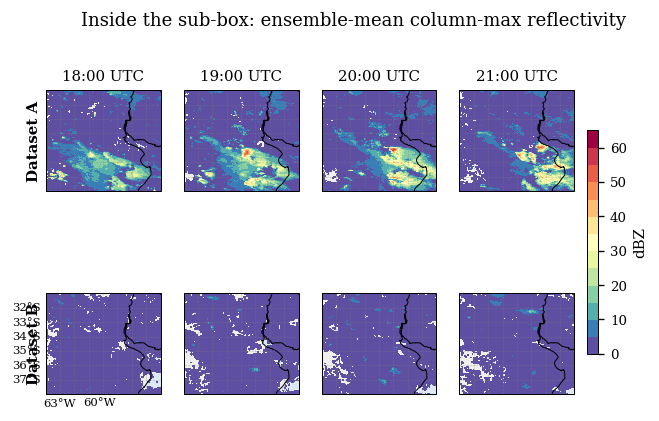

Dataset A  median n_active over echo points: full domain 5   box 5   | echo fraction: full 53.9 %  box 64.1 %
Dataset B  median n_active over echo points: full domain 2   box 2   | echo fraction: full 24.2 %  box 35.7 %


In [12]:
fig, axes = plt.subplots(2, len(HOURS), figsize=(nb.PAGE_W, nb.PAGE_W * 0.60),
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
for r, fam in enumerate(FAMILIES):
    for c, h in enumerate(HOURS):
        ax = axes[r, c]
        nb.setup_map(ax, extent=(min(BBOX_LL["lon"]), max(BBOX_LL["lon"]),
                                 min(BBOX_LL["lat"]), max(BBOX_LL["lat"])),
                     labels=(r == 1 and c == 0))
        f = np.nanmax(BOX[(fam, h)]["dbz_mean"], axis=2)
        pm = nb.map_field(ax, GEO_BOX["lats"], GEO_BOX["lons"],
                          np.where(f > 0, f, np.nan), transform=ccrs.PlateCarree(),
                          cmap=nb.DBZ_CMAP, norm=nb.DBZ_NORM)
        if r == 0: ax.set_title(f"{h}:00 UTC")
        if c == 0: ax.text(-0.10, 0.5, f"Dataset {fam}", transform=ax.transAxes,
                           rotation=90, va="center", ha="center", fontweight="bold")
fig.colorbar(pm, ax=axes, shrink=0.6, pad=0.02, label="dBZ")
fig.suptitle("Inside the sub-box: ensemble-mean column-max reflectivity", y=0.97)
nb.save_fig(fig, "N2_fig8_box_zoom")
plt.show()

for fam in FAMILIES:
    full = STATS[(fam, HOURS[0])]["n_active"]
    box  = BOX[(fam, HOURS[0])]["n_active"]
    print(f"Dataset {fam}  median n_active over echo points: "
          f"full domain {np.median(full[full>0]):.0f}   box {np.median(box[box>0]):.0f}   "
          f"| echo fraction: full {100*(full>0).mean():.1f} %  box {100*(box>0).mean():.1f} %")

## 7 · Handoff

`PRIOR_SUMMARY` is the compact description of the prior that N3 and N4 refer back
to when they ask whether a degradation is a filter problem or was already visible
in the forecast.

In [13]:
rows = []
for (fam, h), s in sorted(STATS.items()):
    cm  = np.nanmax(s["dbz_mean"], axis=2)
    na  = s["n_active"]
    rows.append(dict(dataset=fam, hour=f"{h}:00",
                     max_dbz=round(float(np.nanmax(cm)), 1),
                     area_gt20=int((cm >= 20).sum()),
                     echo_frac=round(float((na > 0).mean()), 4),
                     med_n_active=int(np.median(na[na > 0])) if (na > 0).any() else 0,
                     med_spread=round(float(np.nanmedian(s["dbz_spread"][na > 0])), 2)))
PRIOR_SUMMARY = pd.DataFrame(rows)
PRIOR_SUMMARY.to_csv(nb.DERIVED / "N2_prior_summary.csv", index=False)
print(PRIOR_SUMMARY.to_string(index=False))

print("\nValues the assimilation configs and N3/N4 take from here")
print(f"    HOUR    = {HOURS[0]!r}")
print(f"    NE      = {NE}")
print(f"    dbz_min = {MIN_DBZ}")
print(f"    BBOX    = {BBOX_LL}")

dataset  hour  max_dbz  area_gt20  echo_frac  med_n_active  med_spread
      A 18:00     45.0       1125     0.5395             5        5.61
      A 19:00     55.5       1809     0.5704             5        5.72
      A 20:00     60.1       2708     0.6071             5        6.05
      A 21:00     53.3       2326     0.6166             5        6.21
      B 18:00     29.5         17     0.2421             2        2.94
      B 19:00     32.5         16     0.2385             2        3.03
      B 20:00     33.7         42     0.2627             2        3.33
      B 21:00     32.9         47     0.2839             2        3.66

Values the assimilation configs and N3/N4 take from here
    HOUR    = '18'
    NE      = 60
    dbz_min = 0.0
    BBOX    = {'lat': (-38.0, -31.0), 'lon': (-64.0, -56.0)}
